# Snapshot eval violin plots

Compares **per-episode eval metrics** across the evaluations of one or more snapshots.
`SNAPSHOTS` (next cell) lists the snapshots to analyse; each entry selects which eval
kinds are picked up:

| Struct key | Run directory | Producer | CSVs picked up |
|---|---|---|---|
| `eval-ray` | `runs/eval_<ts>/` | Ray RLlib eval (`run_eval_ray.py`) | `eval_results/*_eval/eval_*.csv` |
| `eval-sb` | `runs/eval_sb_<ts>/` | SB3 eval (`run_eval_sb.py`) | `eval_results/*_eval/eval_*.csv` |
| `eval-rbc` | `runs/eval_rbc_<ts>/` | Rule-based eval (`run_eval_rule_based.py`) | `eval_results/*_rule_based/<strategy>/episodes.csv` |

Each CSV becomes **one violin**; the x-axis shows the rule-based strategy name or the RL
algorithm (read from the JSON summary written next to each RL eval CSV). When several
snapshots are compared, each label additionally carries the snapshot's 1-based index in
`SNAPSHOTS` — e.g. `sac (ray) (2)` — and the figure title maps each index to its snapshot.
Three figures are produced — `total_reward`, `cum_E_kWh` and `cum_price_EUR` — and each is
exported as a PDF into every included snapshot's `stat/` directory (`violin_<metric>.pdf`,
or `violin_<metric>_combined.pdf` when several snapshots are compared, so single-snapshot
exports are never overwritten).

Eval kinds that were **requested but have no CSVs** are reported by the **last cell** of
the notebook.

**Main input:** set `SNAPSHOTS` in the next cell.

In [20]:
# --- Main input: the snapshots to analyse (paths absolute, or relative to the repo root).
# Each entry selects which eval kinds are picked up (missing keys default to True).
# When several snapshots are plotted, violin labels carry the entry's 1-based index, e.g. "sac (ray) (2)";
# the figure title maps each index to the snapshot's "tag" (optional key, defaults to the
# snapshot's leading YYYYmmdd_HHMMSS timestamp).
SNAPSHOTS = [
    {"path": "snapshots/20260703_004926_sta_lin_battery_only_price_sac", "eval-ray": True, "eval-sb": True, "eval-rbc": False},
    {"path": "snapshots/20260704_144904_sta_lin_battery_only_price_ppo", "eval-ray": True, "eval-sb": False, "eval-rbc": False},
    {"path": "snapshots/20260704_183007_sta_lin_battery_only_price_dreamerv3", "eval-ray": True, "eval-sb": False, "eval-rbc": False},
    {"path": "snapshots/20260704_215559_sta_lin_battery_only_price_sac_gam099", "eval-ray": True, "eval-sb": False, "eval-rbc": False},
    {"path": "snapshots/20260704_215614_sta_lin_battery_only_price_ppo_gam099", "eval-ray": True, "eval-sb": False, "eval-rbc": False},
    # {"path": "snapshots/20260705_153845_sta_lin_battery_only_price_sac_short_rfl", "eval-ray": True, "eval-sb": False, "eval-rbc": False}
    {"path": "snapshots/20260705_234931_sta_lin_battery_only_price_rbc_base", "eval-ray": False, "eval-sb": False, "eval-rbc": True}
]


In [21]:
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

EVAL_KINDS = ("eval-ray", "eval-sb", "eval-rbc")


def _find_repo_root() -> Path:
    """Walk upwards from the cwd until the directory containing snapshots/ is found,
    so the notebook runs both from docs/ and from the repo root."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "snapshots").is_dir():
            return candidate
    raise FileNotFoundError("No 'snapshots/' directory found upwards of the cwd — run inside the repo.")


REPO_ROOT = _find_repo_root()


def _default_tag(snapshot_dir: Path) -> str:
    """Leading YYYYmmdd_HHMMSS timestamp of the snapshot name — unique and short enough for the title."""
    match = re.match(r"\d{8}_\d{6}", snapshot_dir.name)
    return match.group(0) if match else snapshot_dir.name


snapshot_specs: list[dict] = []
for index, entry in enumerate(SNAPSHOTS, start=1):
    snapshot_dir = Path(entry["path"])
    snapshot_dir = snapshot_dir if snapshot_dir.is_absolute() else REPO_ROOT / snapshot_dir
    if not snapshot_dir.is_dir():
        raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")
    snapshot_specs.append(
        {
            "index": index,
            "dir": snapshot_dir,
            "tag": entry.get("tag", _default_tag(snapshot_dir)),
            **{kind: bool(entry.get(kind, True)) for kind in EVAL_KINDS},
        }
    )

if not snapshot_specs:
    raise ValueError("SNAPSHOTS is empty — add at least one snapshot entry.")

MULTI_SNAPSHOT = len(snapshot_specs) > 1  # single-snapshot runs keep the plain labels and PDF names

for spec in snapshot_specs:
    requested = ", ".join(kind for kind in EVAL_KINDS if spec[kind])
    print(f"Snapshot ({spec['index']}): {spec['dir']}  [{requested or 'nothing requested'}]")
    print(f"              PDF output → {spec['dir'] / 'stat'}")

Snapshot (1): /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260703_004926_sta_lin_battery_only_price_sac  [eval-ray, eval-sb]
              PDF output → /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260703_004926_sta_lin_battery_only_price_sac/stat
Snapshot (2): /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_144904_sta_lin_battery_only_price_ppo  [eval-ray]
              PDF output → /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_144904_sta_lin_battery_only_price_ppo/stat
Snapshot (3): /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_183007_sta_lin_battery_only_price_dreamerv3  [eval-ray]
              PDF output → /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_183007_sta_lin_battery_only_price_dreamerv3/stat
Snapshot (4): /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_215559_sta_lin_battery_only_price_sac_gam099  [eval-ray]
              PDF output → /hkfs/home/haicore/iai/dj0397/A

## Discover the eval CSVs

One record per CSV, restricted to the eval kinds each `SNAPSHOTS` entry requests.
RL eval CSVs carry a sidecar JSON with the same stem (e.g. `eval_checkpoint_000174_….json`)
whose `algorithm` field names the violin; rule-based violins are named after their strategy
directory. When several snapshots are compared, each label carries the snapshot's 1-based
index in `SNAPSHOTS`, e.g. `sac (ray) (2)`. If two CSVs would still get the same label
(e.g. two checkpoints of one algorithm), a distinguishing suffix is appended.

Eval kinds that were requested but yield no CSVs are collected in `missing_eval_logs`
and reported by the last cell of the notebook.

In [22]:
METRICS = ("total_reward", "cum_E_kWh", "cum_price_EUR")

# Rule-based strategy directories to leave out of the figures entirely
EXCLUDED_STRATEGIES = {"pv_surplus_charge"}

# Seed-sweep run directories (produced by submit_snapshot_eval_seeds.sh, e.g.
# "eval_20260706_120000_seed42") feed the companion snapshot_eval_violins_seeds.ipynb —
# exclude them here so a seed sweep never leaks into the main comparison.
SEED_SWEEP_DIR_REGEX = re.compile(r"_seed-?\d+$")

# Requested-but-absent eval kinds, filled during discovery; the last notebook cell reports these.
missing_eval_logs: list[str] = []


def _sanitise_label(name: str) -> str:
    """Underscores read poorly on the x-axis — display labels use spaces instead."""
    return name.replace("_", " ")


def _algorithm_from_sidecar_json(csv_path: Path) -> str | None:
    sidecar = csv_path.with_suffix(".json")
    if not sidecar.is_file():
        return None
    try:
        return json.loads(sidecar.read_text()).get("algorithm")
    except (json.JSONDecodeError, OSError):
        return None


def _rl_eval_records(run_dir: Path, kind: str) -> list[dict]:
    records = []
    for csv_path in sorted(run_dir.glob("eval_results/*_eval/eval_*.csv")):
        algorithm = _algorithm_from_sidecar_json(csv_path) or "unknown"
        records.append({"label": f"{_sanitise_label(algorithm)} ({kind})", "kind": kind, "csv": csv_path})
    return records


def _rule_based_records(run_dir: Path) -> list[dict]:
    records = []
    for csv_path in sorted(run_dir.glob("eval_results/*_rule_based/*/episodes.csv")):
        if csv_path.parent.name in EXCLUDED_STRATEGIES:
            continue
        records.append({"label": _sanitise_label(csv_path.parent.name), "kind": "rule-based", "csv": csv_path})
    return records


def _run_dir_eval_kind(run_dir: Path) -> str:
    """Map a runs/eval_* directory to its SNAPSHOTS struct key."""
    if run_dir.name.startswith("eval_rbc_"):
        return "eval-rbc"
    if run_dir.name.startswith("eval_sb_"):
        return "eval-sb"
    return "eval-ray"


def _eval_results_subdir_name(csv_path: Path) -> str:
    """Name of the timestamped directory directly below eval_results/ — used to disambiguate labels."""
    for parent in csv_path.parents:
        if parent.parent.name == "eval_results":
            return parent.name
    return csv_path.parent.name


def _deduplicate_labels(records: list[dict]) -> None:
    counts = Counter(record["label"] for record in records)
    for record in records:
        if counts[record["label"]] > 1:
            checkpoint = re.search(r"checkpoint_(\d+)", record["csv"].name)
            suffix = f"ckpt {int(checkpoint.group(1))}" if checkpoint else _sanitise_label(_eval_results_subdir_name(record["csv"]))
            record["label"] = f"{record['label']} [{suffix}]"


def discover_eval_csvs(spec: dict) -> list[dict]:
    """Scan <snapshot>/runs/eval_* for the eval kinds `spec` requests; log requested-but-absent kinds."""
    records_per_kind: dict[str, list[dict]] = {kind: [] for kind in EVAL_KINDS}
    for run_dir in sorted((spec["dir"] / "runs").glob("eval_*")):
        if SEED_SWEEP_DIR_REGEX.search(run_dir.name):
            continue
        eval_kind = _run_dir_eval_kind(run_dir)
        if not spec[eval_kind]:
            continue
        if eval_kind == "eval-rbc":
            records_per_kind[eval_kind].extend(_rule_based_records(run_dir))
        else:
            records_per_kind[eval_kind].extend(_rl_eval_records(run_dir, "sb3" if eval_kind == "eval-sb" else "ray"))
    for eval_kind in EVAL_KINDS:
        if spec[eval_kind] and not records_per_kind[eval_kind]:
            missing_eval_logs.append(f"{spec['dir'].name}: '{eval_kind}' requested but no eval CSVs found")
    records = [record for eval_kind in EVAL_KINDS for record in records_per_kind[eval_kind]]
    for record in records:
        record["snapshot_index"] = spec["index"]
        record["snapshot"] = spec["dir"].name
        if MULTI_SNAPSHOT:
            record["label"] = f"{record['label']} ({spec['index']})"
    return records


def _display_path(csv_path: Path) -> str:
    try:
        return str(csv_path.relative_to(REPO_ROOT))
    except ValueError:
        return str(csv_path)


eval_records: list[dict] = []
for spec in snapshot_specs:
    eval_records.extend(discover_eval_csvs(spec))
_deduplicate_labels(eval_records)
if not eval_records:
    raise FileNotFoundError(f"No eval CSVs found for any requested snapshot/eval-kind combination: {missing_eval_logs}")

pd.DataFrame(
    {
        "label": record["label"],
        "kind": record["kind"],
        "snapshot_index": record["snapshot_index"],
        "snapshot": record["snapshot"],
        "csv": _display_path(record["csv"]),
    }
    for record in eval_records
)

,label,kind,snapshot_index,snapshot,csv
0,sac (ray) (1),ray,1,20260703_004926_sta_lin_battery_only_price_sac,snapshots/20260703_004926_sta_lin_battery_only...
1,ppo (ray) (2),ray,2,20260704_144904_sta_lin_battery_only_price_ppo,snapshots/20260704_144904_sta_lin_battery_only...
2,dreamerv3 (ray) (3),ray,3,20260704_183007_sta_lin_battery_only_price_dre...,snapshots/20260704_183007_sta_lin_battery_only...
3,sac (ray) (4),ray,4,20260704_215559_sta_lin_battery_only_price_sac...,snapshots/20260704_215559_sta_lin_battery_only...
4,ppo (ray) (5),ray,5,20260704_215614_sta_lin_battery_only_price_ppo...,snapshots/20260704_215614_sta_lin_battery_only...
5,deficit discharge (6),rule-based,6,20260705_234931_sta_lin_battery_only_price_rbc...,snapshots/20260705_234931_sta_lin_battery_only...
6,do nothing (6),rule-based,6,20260705_234931_sta_lin_battery_only_price_rbc...,snapshots/20260705_234931_sta_lin_battery_only...
7,price median (6),rule-based,6,20260705_234931_sta_lin_battery_only_price_rbc...,snapshots/20260705_234931_sta_lin_battery_only...
8,price median autarky (6),rule-based,6,20260705_234931_sta_lin_battery_only_price_rbc...,snapshots/20260705_234931_sta_lin_battery_only...
9,price median scaled 0.25 (6),rule-based,6,20260705_234931_sta_lin_battery_only_price_rbc...,snapshots/20260705_234931_sta_lin_battery_only...


## Load per-episode metrics

All CSVs are concatenated into one long-format frame. RL violins are drawn first on the
x-axis, rule-based strategies after them. A CSV missing one of the metric columns is
simply absent from that metric's figure.

In [23]:
frames = []
for record in eval_records:
    csv_frame = pd.read_csv(record["csv"])
    missing = [metric for metric in METRICS if metric not in csv_frame.columns]
    if missing:
        print(f"note: '{record['label']}' has no {missing} column(s) — skipped in those figures")
    frame = csv_frame[[metric for metric in METRICS if metric in csv_frame.columns]].copy()
    frame["label"] = record["label"]
    frame["kind"] = record["kind"]
    frame["group"] = "RBC" if record["kind"] == "rule-based" else "RL"
    frames.append(frame)

episodes = pd.concat(frames, ignore_index=True)

# RL violins first, then the rule-based strategies
label_order = [r["label"] for r in eval_records if r["kind"] != "rule-based"] + [
    r["label"] for r in eval_records if r["kind"] == "rule-based"
]

episodes.groupby(["label", "kind"], sort=False).agg(
    episodes=("total_reward", "size"),
    mean_total_reward=("total_reward", "mean"),
    mean_cum_E_kWh=("cum_E_kWh", "mean"),
    mean_cum_price_EUR=("cum_price_EUR", "mean"),
)

,,episodes,mean_total_reward,mean_cum_E_kWh,mean_cum_price_EUR
label,kind,,,,
sac (ray) (1),ray,10,14.235960,42.087546,-3.463104
ppo (ray) (2),ray,10,13.471870,46.765021,-3.618641
dreamerv3 (ray) (3),ray,10,13.714172,46.765021,-3.793500
sac (ray) (4),ray,10,14.704845,46.193189,-3.875770
ppo (ray) (5),ray,10,13.619143,46.765021,-3.734709
deficit discharge (6),rule-based,10,4.476308,35.926459,-1.308588
do nothing (6),rule-based,10,6.404487,43.916713,-1.862668
price median (6),rule-based,10,6.676441,39.796023,-1.837752
price median autarky (6),rule-based,10,7.169610,43.916713,-2.094971


## Violin plots

One violin per CSV; individual episodes overlaid as dots. Colour distinguishes RL policies
(blue) from rule-based strategies (green). Each violin carries two stat markers:
**mean** (red dot) and **median** (narrow dashed line). Each figure is saved into every
included snapshot's `stat/` directory — as `violin_<metric>.pdf` for a single snapshot,
or `violin_<metric>_combined.pdf` when several snapshots are compared.

`violin_for_metric(metric, title_override=...)` replaces the default
`<metric> — <snapshots>` figure title with the given string.

In [24]:
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid", context="notebook")

GROUP_COLORS = {"RL": "#75aef4", "RBC": "#89f0cc"}
METRIC_LABELS = {
    "total_reward": "Total reward per episode",
    "cum_E_kWh": "Cumulative energy consumption [kWh]",
    "cum_price_EUR": "Cumulative energy price [EUR]",
}

# Stat markers drawn on top of each violin (replaces seaborn's faint inner box)
MEAN_COLOR = "#e34948"  # red dot
MEDIAN_COLOR = "#1a1a19"  # narrow dashed line
MEDIAN_DASH = (0, (4, 2))

# Single snapshot keeps the full name in the title; several snapshots list their index → tag mapping,
# resolving the "(i)" suffix each violin label carries
FIGURE_TITLE_SUFFIX = (
    ", ".join(f"({spec['index']}) {spec['tag']}" for spec in snapshot_specs)
    if MULTI_SNAPSHOT
    else snapshot_specs[0]["dir"].name
)
# Combined figures get their own PDF name so single-snapshot exports are never overwritten
PDF_STEM_SUFFIX = "_combined" if MULTI_SNAPSHOT else ""


def _draw_stat_markers(ax, data: pd.DataFrame, metric: str) -> None:
    """Overlay the mean (red dot) and median (narrow dashed line) of each violin."""
    stats = data.groupby("label")[metric].agg(["mean", "median"])
    for x_position, label in enumerate(label_order):
        if label not in stats.index:
            continue
        row = stats.loc[label]
        ax.hlines(
            row["median"], x_position - 0.23, x_position + 0.23,
            color=MEDIAN_COLOR, linewidth=0.9, linestyle=MEDIAN_DASH, zorder=5,
        )
        ax.scatter(
            x_position, row["mean"],
            color=MEAN_COLOR, s=18, edgecolor="white", linewidth=0.5, zorder=6,
        )


def violin_for_metric(metric: str, title_override: str | None = None) -> None:
    """Draw one violin per eval CSV for `metric` and export the figure as a PDF into each snapshot's stat/.

    `title_override` replaces the default "<metric> — <snapshots>" figure title when given."""
    data = episodes.dropna(subset=[metric]) if metric in episodes.columns else episodes.iloc[0:0]
    if data.empty:
        print(f"no data for '{metric}' — figure skipped")
        return

    figure_width = max(8.0, 1.15 * len(label_order))
    fig, ax = plt.subplots(figsize=(figure_width, 5.0))
    sns.violinplot(
        data=data,
        x="label",
        y=metric,
        hue="group",
        order=label_order,
        hue_order=list(GROUP_COLORS),
        palette=GROUP_COLORS,
        dodge=False,  # hue only colours the violins; every label keeps its own x position
        density_norm="area",
        # cut=0,  # do not extrapolate the KDE beyond observed episode values
        inner=None,  # the stat markers below replace seaborn's faint inner box
        linewidth=1.0,
        saturation=1.0,
        ax=ax,
    )
    sns.stripplot(
        data=data, x="label", y=metric, order=label_order,
        color="0.1", size=3, alpha=0.6, jitter=0.08, ax=ax,
    )
    _draw_stat_markers(ax, data, metric)

    ax.set_xlabel("")
    ax.set_ylabel(METRIC_LABELS.get(metric, metric))
    ax.set_title(title_override if title_override else f"{metric} — {FIGURE_TITLE_SUFFIX}", pad=12)
    ax.grid(axis="x", visible=False)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

    group_handles, group_labels = ax.get_legend_handles_labels()
    stat_handles = [
        Line2D([], [], color=MEAN_COLOR, marker="o", linestyle="none", markersize=5,
            markeredgewidth=0.5, label="mean"),
        Line2D([], [], color=MEDIAN_COLOR, linewidth=0.9, linestyle=MEDIAN_DASH, label="median"),
    ]
    # Legend outside the axes so it never covers a violin
    ax.legend(
        handles=group_handles + stat_handles,
        labels=group_labels + [handle.get_label() for handle in stat_handles],
        title="", frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0,
    )
    sns.despine(ax=ax)
    fig.tight_layout()

    for spec in snapshot_specs:
        stat_dir = spec["dir"] / "stat"
        stat_dir.mkdir(parents=True, exist_ok=True)
        pdf_path = stat_dir / f"violin_{metric}{PDF_STEM_SUFFIX}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"saved {pdf_path}")
    plt.show()

saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260703_004926_sta_lin_battery_only_price_sac/stat/violin_total_reward_combined.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_144904_sta_lin_battery_only_price_ppo/stat/violin_total_reward_combined.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_183007_sta_lin_battery_only_price_dreamerv3/stat/violin_total_reward_combined.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_215559_sta_lin_battery_only_price_sac_gam099/stat/violin_total_reward_combined.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_215614_sta_lin_battery_only_price_ppo_gam099/stat/violin_total_reward_combined.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260705_234931_sta_lin_battery_only_price_rbc_base/stat/violin_total_reward_combined.pdf


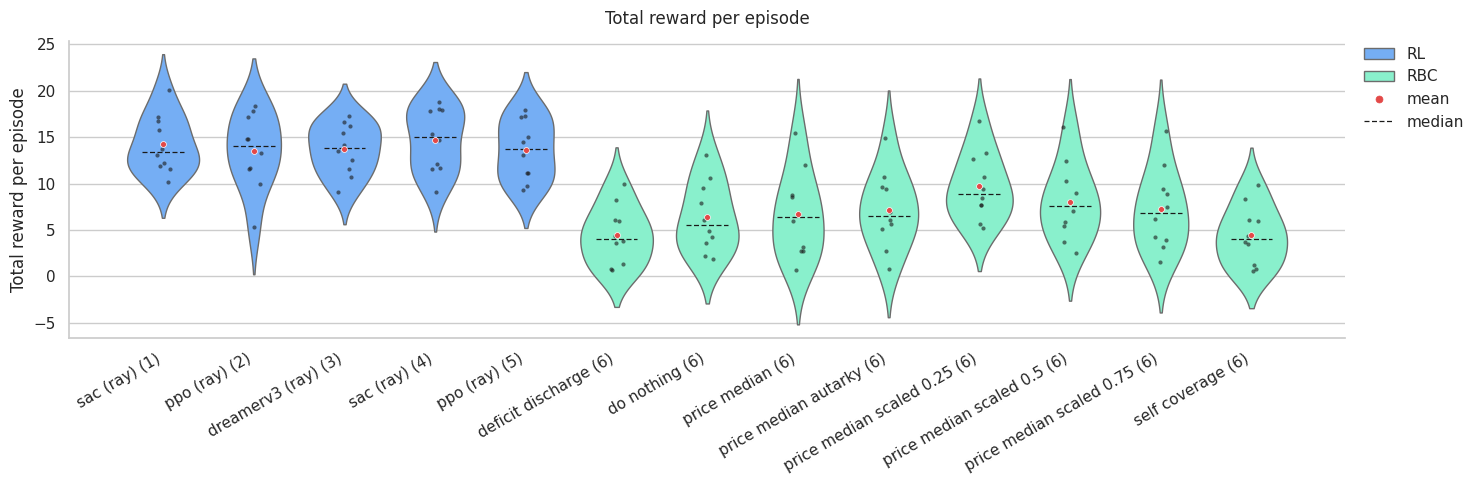

In [25]:
violin_for_metric("total_reward", 
    title_override=f"Total reward per episode")

saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260703_004926_sta_lin_battery_only_price_sac/stat/violin_cum_E_kWh_combined.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_144904_sta_lin_battery_only_price_ppo/stat/violin_cum_E_kWh_combined.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_183007_sta_lin_battery_only_price_dreamerv3/stat/violin_cum_E_kWh_combined.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_215559_sta_lin_battery_only_price_sac_gam099/stat/violin_cum_E_kWh_combined.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_215614_sta_lin_battery_only_price_ppo_gam099/stat/violin_cum_E_kWh_combined.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260705_234931_sta_lin_battery_only_price_rbc_base/stat/violin_cum_E_kWh_combined.pdf


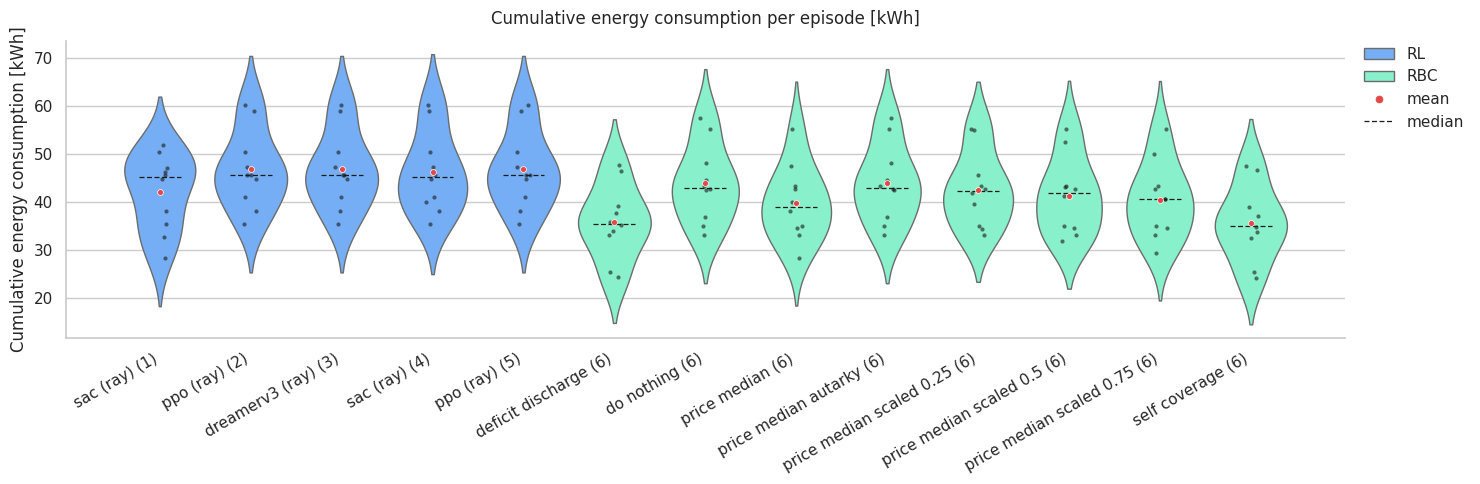

In [26]:
violin_for_metric("cum_E_kWh",
	title_override=f"Cumulative energy consumption per episode [kWh]")

saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260703_004926_sta_lin_battery_only_price_sac/stat/violin_cum_price_EUR_combined.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_144904_sta_lin_battery_only_price_ppo/stat/violin_cum_price_EUR_combined.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_183007_sta_lin_battery_only_price_dreamerv3/stat/violin_cum_price_EUR_combined.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_215559_sta_lin_battery_only_price_sac_gam099/stat/violin_cum_price_EUR_combined.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260704_215614_sta_lin_battery_only_price_ppo_gam099/stat/violin_cum_price_EUR_combined.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260705_234931_sta_lin_battery_only_price_rbc_base/stat/violin_cum_price_EUR_combined.pdf


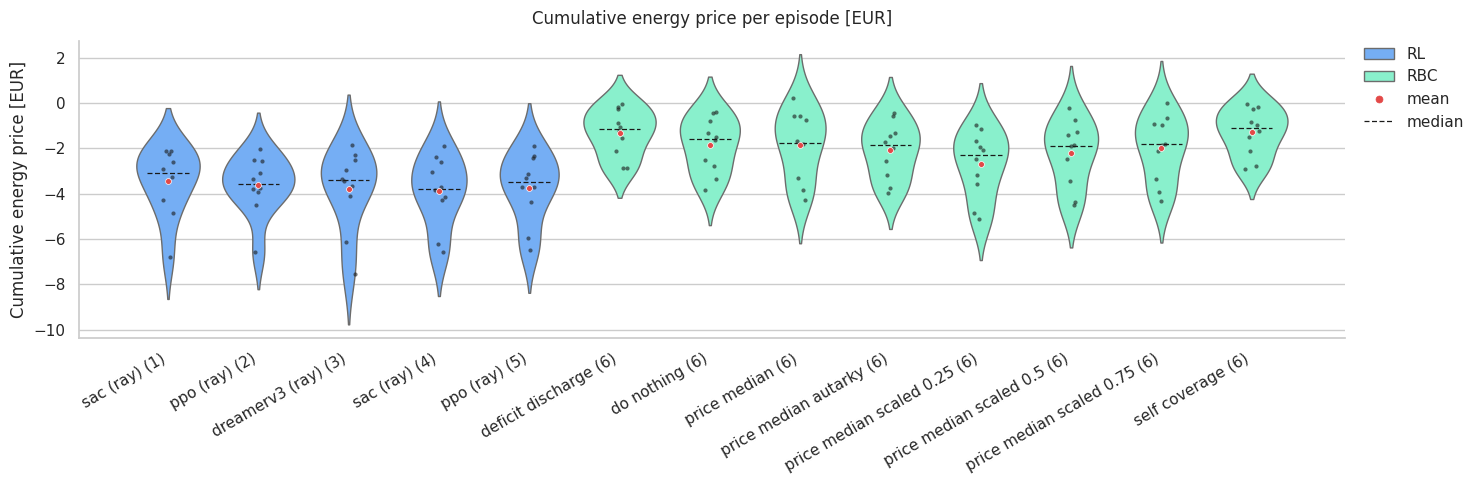

In [27]:
violin_for_metric("cum_price_EUR", 
    title_override=f"Cumulative energy price per episode [EUR]")

## Missing requested evals

One log line per eval kind that a `SNAPSHOTS` entry requested but for which the discovery
found no CSVs (missing `runs/eval_*` directory or an empty one).

In [28]:
if missing_eval_logs:
    for log_line in missing_eval_logs:
        print(f"WARNING: {log_line}")
else:
    print("All requested eval kinds were found in every snapshot.")